<a href="https://colab.research.google.com/github/tzmjoseph/UT_Austin_PGP_AIML_Projects/blob/main/Thomas_Joseph_EasyVisa_Full_Code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 23.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Import Dataset

In [ ]:
# Mounting Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading dataset
easy_visa_data = pd.read_csv('/content/drive/MyDrive/Learning/UT Austin/03 - Advanced Machine Learning/Project/EasyVisa.csv')

In [ ]:
# Taking a copy for analysis, data prep-processing and modeling
data = easy_visa_data.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
# Reading first 5 rows of data
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# Reading last 5 rows of data
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
# Checking number of rows and columns
data.shape

(25480, 12)

**Observations**

*   There are 25,480 observations/ data points (rows) and 12 features / variables (columns) in the data.



#### Check the data types of the columns for the dataset

In [ ]:
# Check the data types and columns

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
# Check if there is any duplicate data
data.duplicated().sum()

np.int64(0)

In [ ]:
# Check if there is any missing data
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
# Checking statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


#### Fixing the negative values in number of employees columns

In [ ]:
# Find the rows where no_of_employees is negative
data[data['no_of_employees'] < 0]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [ ]:
# Print the number of rows where the no_of_employees is negative
data[data['no_of_employees'] < 0].shape[0]

33

In [ ]:
# Replacing value of no_of_employees with absolute values
data['no_of_employees'] = abs(data['no_of_employees'])

In [ ]:
# Confirm that all data was coverted to positive values
data[data['no_of_employees'] < 0].shape[0]

0

#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Get list of all object columns in data into a list
object_cols = data.select_dtypes(include=['object']).columns.tolist()

# Loop through the object_cols and print the number of unique values for each one
for col in object_cols:
    print(data[col].value_counts())
    print('---------------------------------------------------------------------------------')

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
---------------------------------------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
---------------------------------------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
---------------------------------------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
---------------------------------------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
---------------

**Observations**


*   **case_id**: This has 25480 unique values which means it is unique for each row and can be dropped before building the model
*   **continent**: This has 6 unique values
*   **education_of_employee**: This has 4 unique values
*   **has_job_experience**, **requires_job_training**, **full_time_position**: These are indicators and have 2 unique values for each column (Y and N)
*   **region_of_employment**: This has 5 unique values
*   **unit_of_wage**: This has 4 unique values
*   **case_status** (target vaiable): This has 2 unique values



In [ ]:
# Drop case_id column from data
data.drop('case_id', axis=1, inplace=True)

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

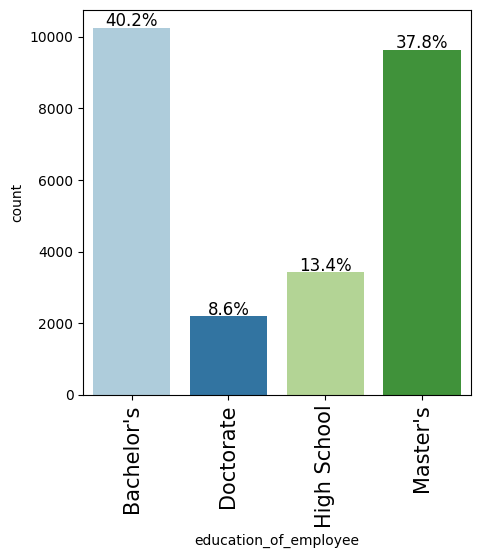

In [ ]:
# Create labeled barplot for education_of_employee
labeled_barplot(data, 'education_of_employee', perc=True)

#### Observations on region of employment

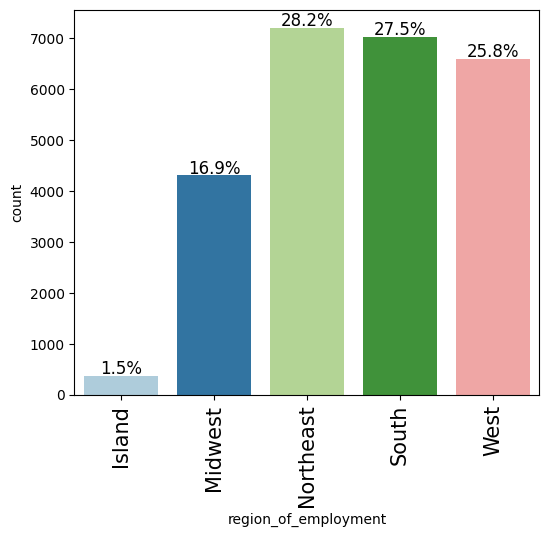

In [ ]:
# Create labeled barplot for region_of_employment
labeled_barplot(data, 'region_of_employment', perc=True)

#### Observations on job experience

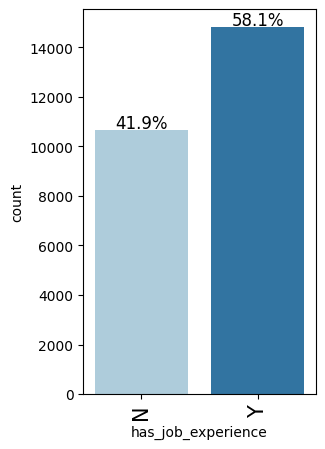

In [ ]:
# Create labeled barplot for job_experience
labeled_barplot(data, 'has_job_experience', perc=True)

#### Observations on case status

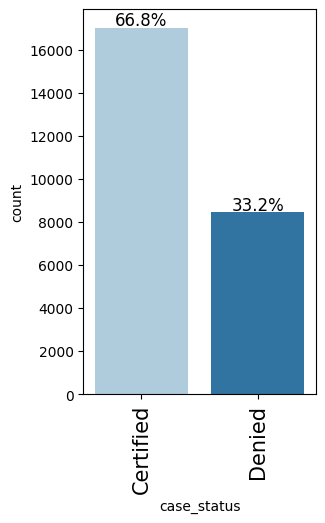

In [ ]:
# Create labeled barplot for case_status
labeled_barplot(data, 'case_status', perc=True)

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Check Correlation

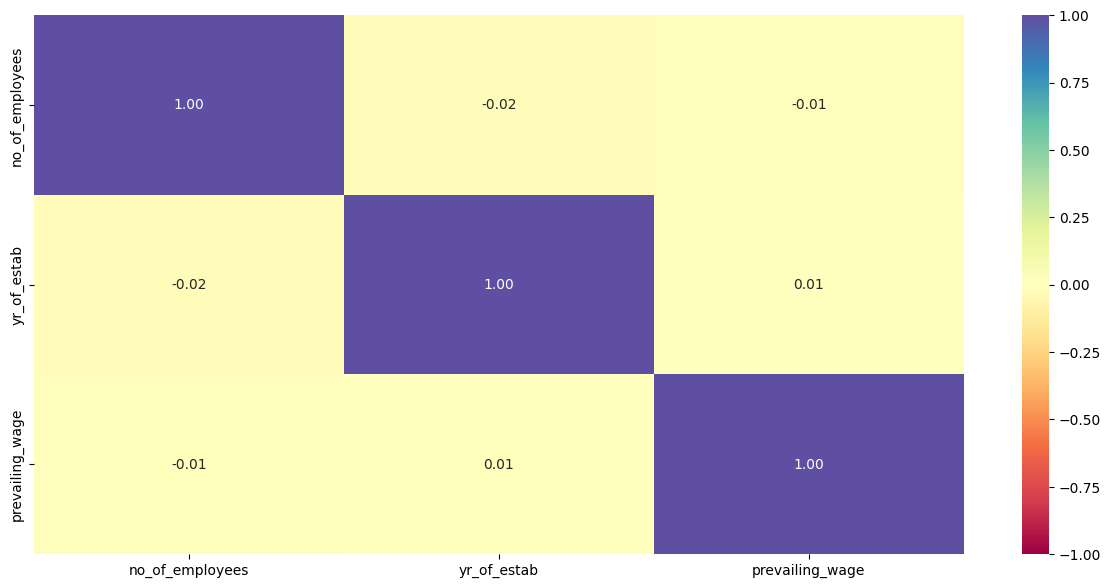

In [ ]:
# Draw heatmap for numeric columns
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


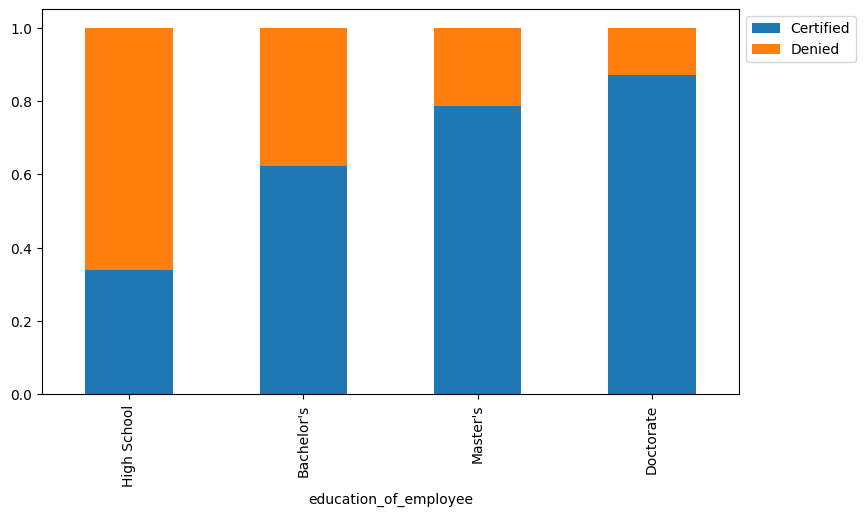

In [ ]:
# Create stacked barplot for education_of_employee against case_status
stacked_barplot(data, 'education_of_employee', 'case_status')

**Observations**


*   Yes, chances of being certified increase as you earn higher education
*   Applicants with only a High School education are more likely to be denied than certified



#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


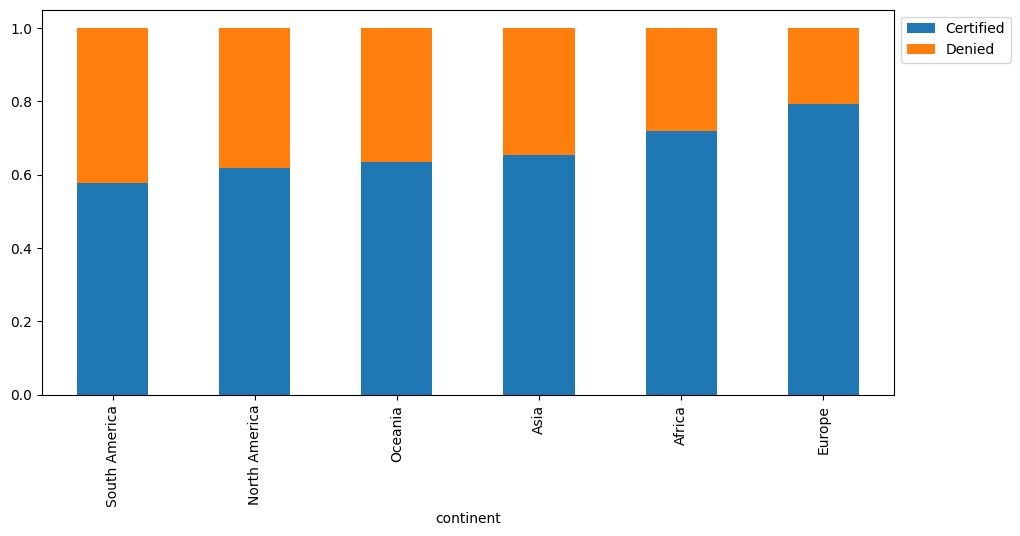

In [ ]:
# Create stacked barplot for continent against case_status
stacked_barplot(data, 'continent', 'case_status')

**Observations**


*   Chances of being certified are within a 20% range across all continents
*   Europe has a higher chance of certification compared to other continents



#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


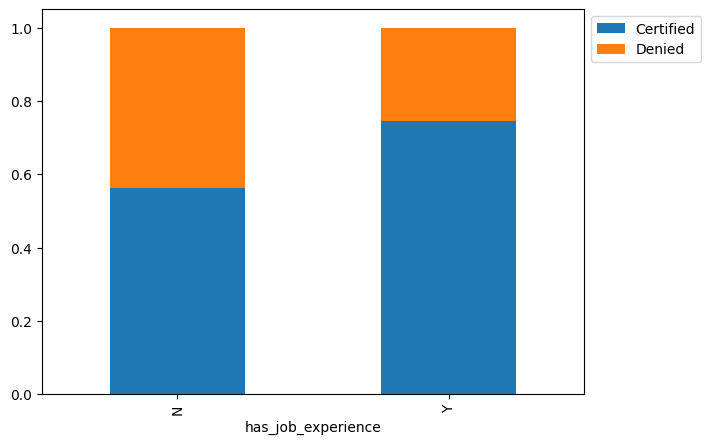

In [ ]:
# Create stacked barplot for has_prior_experience against case_status
stacked_barplot(data, 'has_job_experience', 'case_status')

**Observations**


*   Yes, applicants with prior job experience have a slightly better change of being certified



#### Is the prevailing wage consistent across all regions of the US?

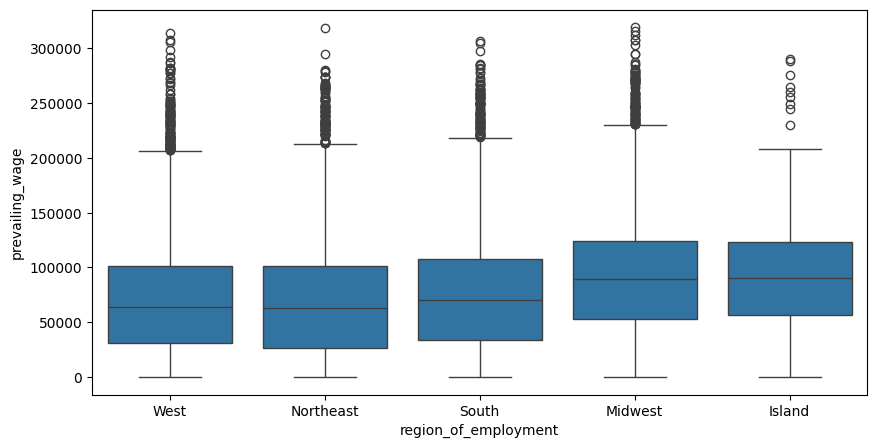

In [ ]:
# Creating boxplot of prevailing_wage against region_of_employment
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='region_of_employment', y='prevailing_wage')
plt.show()

**Observations**


*   Prevailing wage is consistent across West, Northesat and South
*   Prevailing wage is consistent across Midwest and Island
*   Midwest and Island are slight higer compared to West, Northeast and South




case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


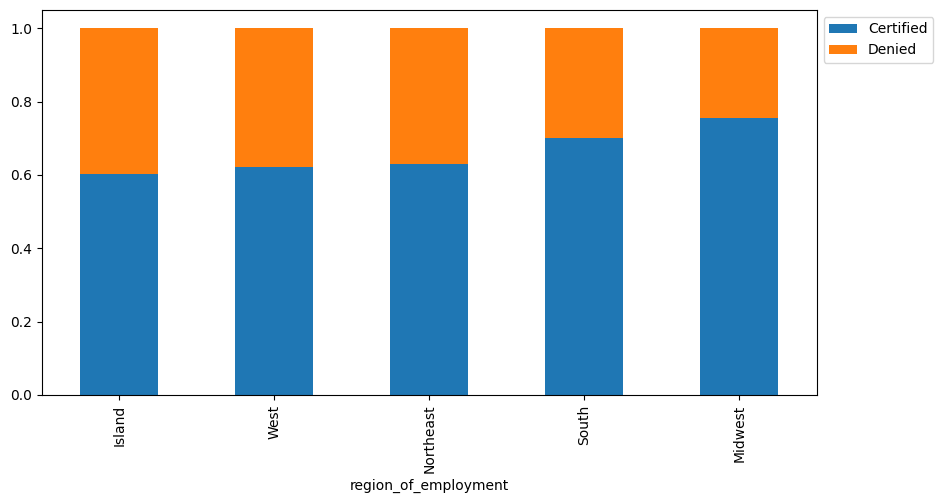

In [ ]:
# Check case status by region of employment
stacked_barplot(data, 'region_of_employment', 'case_status')

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

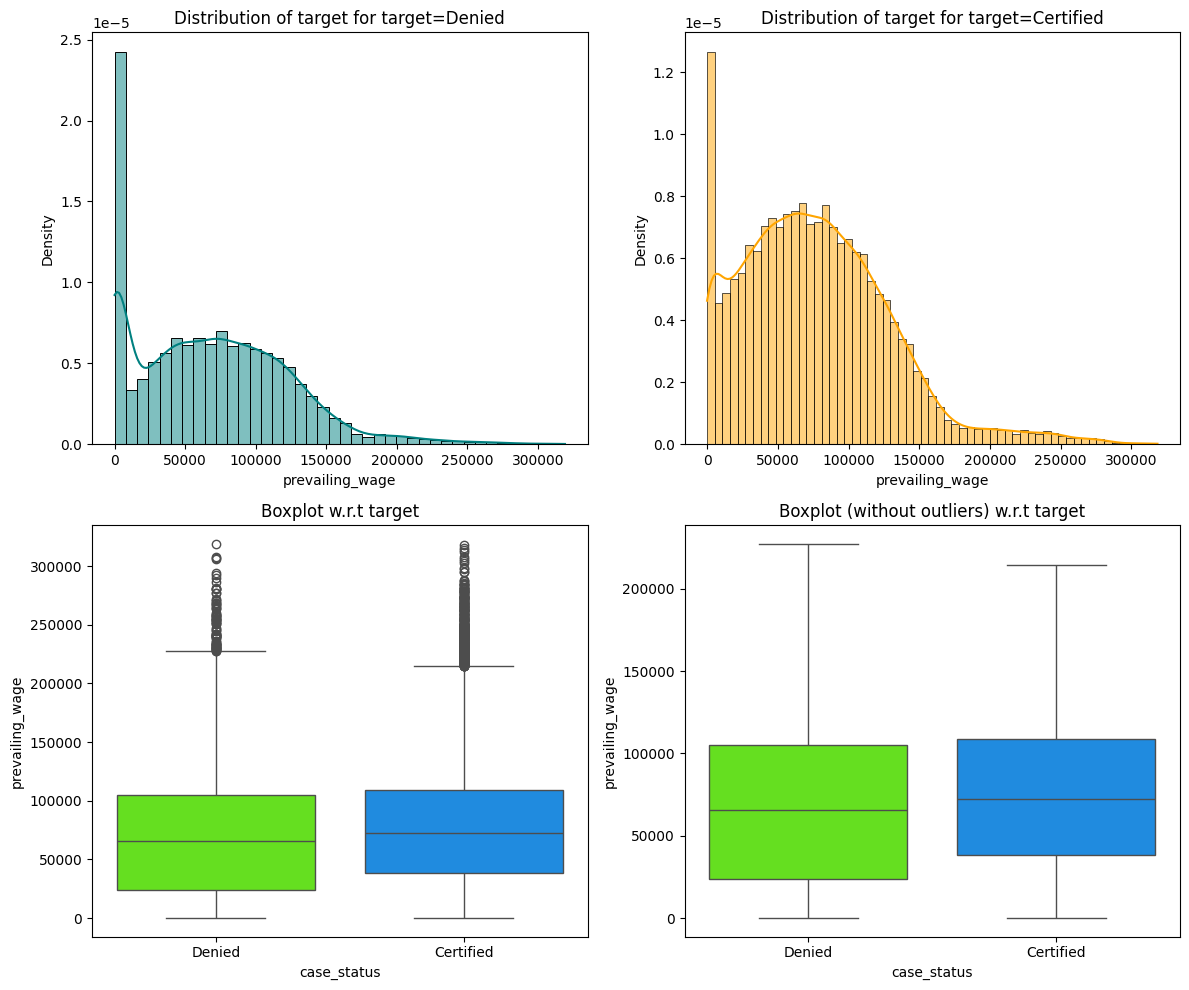

In [ ]:
# Create a distribution plot between prevailing_wage and case_status
distribution_plot_wrt_target(data, 'prevailing_wage', 'case_status')

**Observations**


*   Applicants for a  job with a very low prevailing wage are more liekly to be denied
*   In all other cases chance of certification and denial are the same



#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


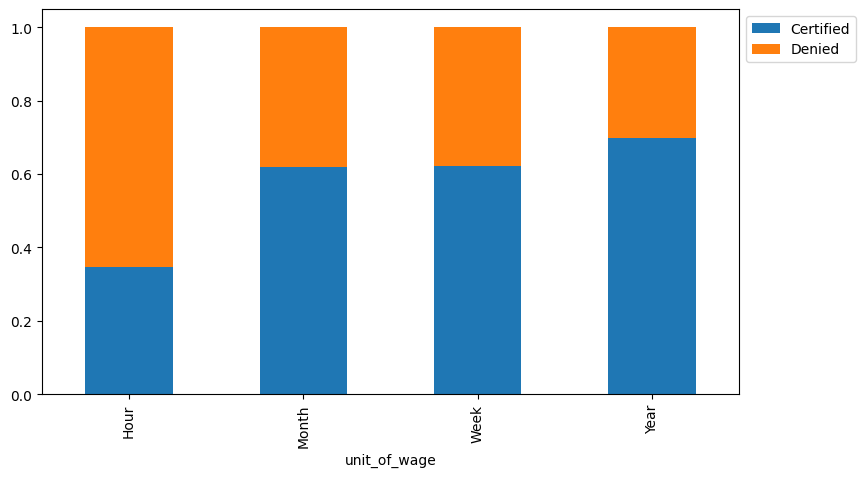

In [ ]:
# Create stacked barplot of unit_Of_wage against case_satus
stacked_barplot(data, 'unit_of_wage', 'case_status')

**Observations**


*   Yes, applicants paid hourly are more likely to be Denied than applicants paid monthly, weekly or yearly



## Data Pre-processing

### Outlier Check

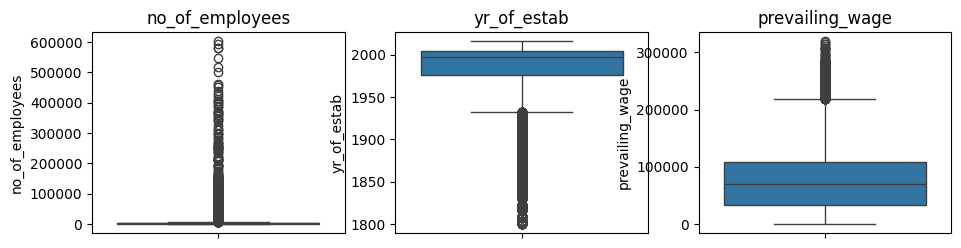

In [ ]:
# Checking outliers for all numeric columns in the data
plt.figure(figsize=(15, 12))

cols = data.select_dtypes(include=np.number).columns

for i, col in enumerate(cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(data[col], whis=1.5)
    plt.title(col)

plt.show()

**Observations**


*   Number of Employees, Year of Establishment and Prevailing vage have outliers but these are reasonable
*   Outliers do not require to be addressed



### Data Preparation for modeling

In [ ]:
# Convert case_status values to 1 for Certified and 0 otherwise (Denied)
data['case_status'] = data['case_status'].apply(lambda x: 1 if x == 'Certified' else 0)

In [ ]:
# Mapping columns having Yes and No values to 1 for Yes and 0 for No
data['has_job_experience'] = data['has_job_experience'].map({'Y': 1, 'N': 0})
data['requires_job_training'] = data['requires_job_training'].map({'Y': 1, 'N': 0})
data['full_time_position'] = data['full_time_position'].map({'Y': 1, 'N': 0})

In [ ]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,0,0,14513,2007,West,592.2029,Hour,1,0
1,Asia,Master's,1,0,2412,2002,Northeast,83425.6500,Year,1,1
2,Asia,Bachelor's,0,1,44444,2008,West,122996.8600,Year,1,0
3,Asia,Bachelor's,0,0,98,1897,West,83434.0300,Year,1,0
4,Africa,Master's,1,0,1082,2005,South,149907.3900,Year,1,1


In [ ]:
data.tail()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,Asia,Bachelor's,1,1,2601,2008,South,77092.57,Year,1,1
25476,Asia,High School,1,0,3274,2006,Northeast,279174.79,Year,1,1
25477,Asia,Master's,1,0,1121,1910,South,146298.85,Year,0,1
25478,Asia,Master's,1,1,1918,1887,West,86154.77,Year,1,1
25479,Asia,Bachelor's,1,0,3195,1960,Midwest,70876.91,Year,1,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  int64  
 3   requires_job_training  25480 non-null  int64  
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  int64  
 10  case_status            25480 non-null  int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 2.1+ MB


In [ ]:
# Create X and y from data
X = data.drop('case_status', axis=1)
y = data['case_status']

In [ ]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)

(25480, 21)


In [ ]:
# Split X and y into Train, Validaation and Test splits using a 50:25:25 ratio

# First split X and y into train and temp data using a 50% split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=1, stratify=y)

# Next split  temp further into validation and testing using a 50% split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp)

In [ ]:
# Check size of splits and class percentages
print(f'Shape of Training set: {X_train.shape}')
print(f'Shape of Validation set: {X_val.shape}')
print(f'Shape of Test set: {X_test.shape}')
print('')
print(f'Class percentage in Train set: {y_train.value_counts(normalize=True)}')
print(f'Class percentage in Validation set: {y_val.value_counts(normalize=True)}')
print(f'Class percentage in Test set: {y_test.value_counts(normalize=True)}')

Shape of Training set: (12740, 21)
Shape of Validation set: (6370, 21)
Shape of Test set: (6370, 21)

Class percentage in Train set: case_status
1    0.667896
0    0.332104
Name: proportion, dtype: float64
Class percentage in Validation set: case_status
1    0.667818
0    0.332182
Name: proportion, dtype: float64
Class percentage in Test set: case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

In [ ]:
scorer = metrics.make_scorer(metrics.f1_score)

### Model building with Original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

results_original = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold, n_jobs =-1
    )
    results_original.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: Training Score = {}; Validation Score = {}".format(name, scores_train, scores_val))



Cross-Validation performance on training dataset:

Bagging: 0.7817495496069341
Random forest: 0.8080662297365251
GBM: 0.8253216979709286
Adaboost: 0.8231013024633359
Xgboost: 0.8074011842009057
dtree: 0.7516068653722633

Performance:

Bagging: Training Score = 0.989396795475966; Validation Score = 0.7751106968072711
Random forest: Training Score = 1.0; Validation Score = 0.8033098512803309
GBM: Training Score = 0.8343040994064459; Validation Score = 0.8209103998227932
Adaboost: Training Score = 0.8261863299956465; Validation Score = 0.8166014776184267
Xgboost: Training Score = 0.9061514195583596; Validation Score = 0.8033080017881091
dtree: Training Score = 1.0; Validation Score = 0.7429652400094585


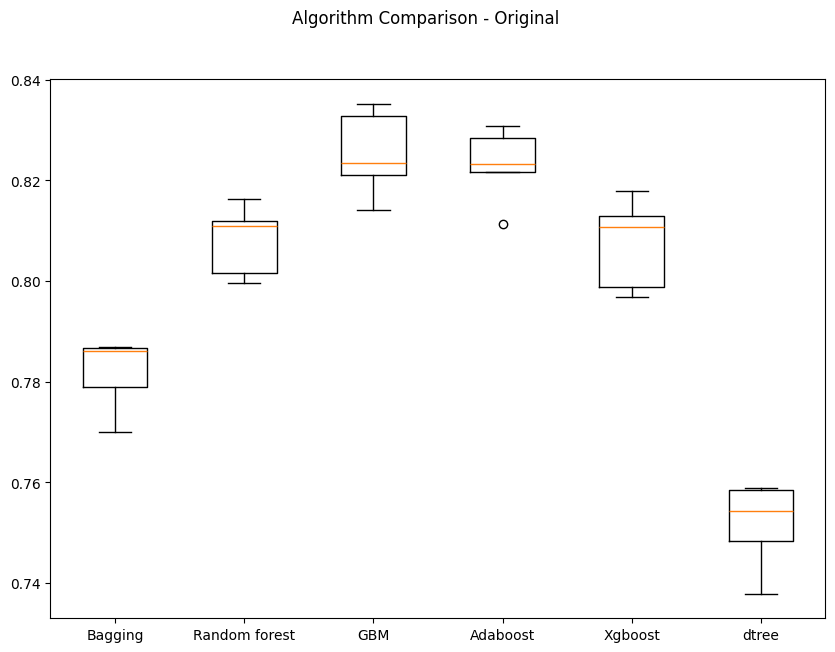

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison - Original")
ax = fig.add_subplot(111)
plt.boxplot(results_original)
ax.set_xticklabels(names)

plt.show()


### Model Building with Oversampled data

In [ ]:
# Show count of labels before oversampling
print("-"*50)
print("Before oversampling value counts for case status")
print(y_train.value_counts())
print("-"*50)

--------------------------------------------------
Before oversampling value counts for case status
case_status
1    8509
0    4231
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)
print()

In [ ]:
# Show count of labels after oversampling
print("-"*50)
print("After oversampling value counts for case status")
print(y_train_over.value_counts())
print("-"*50)

--------------------------------------------------
After oversampling value counts for case status
case_status
1    8509
0    8509
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

results_over = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold, n_jobs =-1
    )
    results_over.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: Training Score = {}; Validation Score = {}".format(name, scores_train, scores_val))




Cross-Validation performance on training dataset:

Bagging: 0.7721661050140155
Random forest: 0.8015017878036901
GBM: 0.8095384903816875
Adaboost: 0.7934502072373603
Xgboost: 0.8054843749916607
dtree: 0.738533638225387

Performance:

Bagging: Training Score = 0.9858705291161691; Validation Score = 0.7652006729151646
Random forest: Training Score = 1.0; Validation Score = 0.7958786491127647
GBM: Training Score = 0.8134598012646793; Validation Score = 0.8107984964118921
Adaboost: Training Score = 0.7943658759124088; Validation Score = 0.7956566940048516
Xgboost: Training Score = 0.8885625529511437; Validation Score = 0.8009489380930863
dtree: Training Score = 1.0; Validation Score = 0.7346158441868802


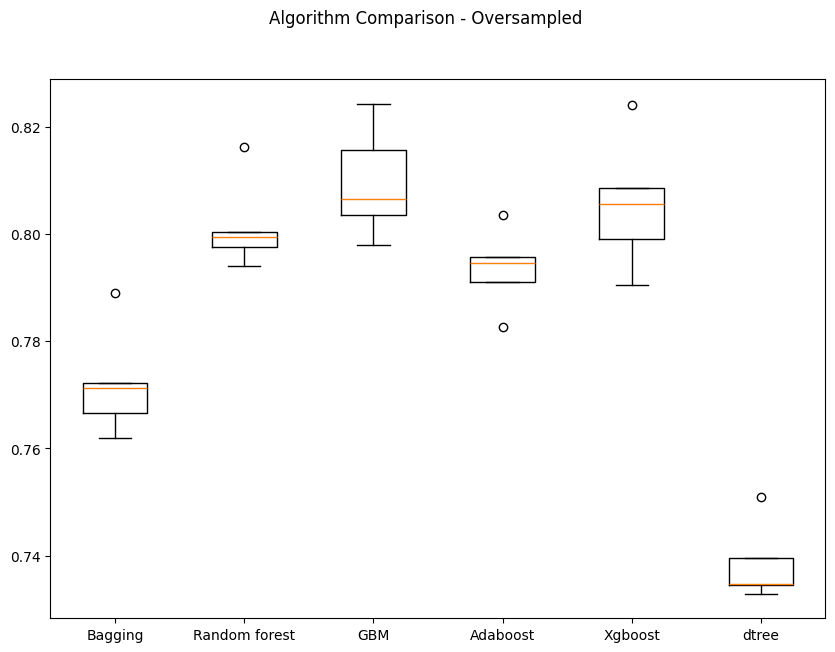

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison - Oversampled")
ax = fig.add_subplot(111)
plt.boxplot(results_over)
ax.set_xticklabels(names)

plt.show()

### Model Building with Undersampled data

In [ ]:
# Creating undersampling training sets
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
# Show count of labels before undersampling
print("-"*50)
print("Before undersampling value counts for case status")
print(y_train.value_counts())
print("-"*50)

--------------------------------------------------
Before undersampling value counts for case status
case_status
1    8509
0    4231
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
# Show count of labels after undersampling
print("-"*50)
print("After undersampling value counts for case status")
print(y_train_un.value_counts())
print("-"*50)

--------------------------------------------------
After undersampling value counts for case status
case_status
0    4231
1    4231
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

results_un = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold, n_jobs =-1
    )
    results_un.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: Training Score = {}; Validation Score = {}".format(name, scores_train, scores_val))



Cross-Validation performance on training dataset:

Bagging: 0.652416916989217
Random forest: 0.694971391075702
GBM: 0.7125612383110675
Adaboost: 0.7069407677966683
Xgboost: 0.6906598022198174
dtree: 0.6299364635725562

Performance:

Bagging: Training Score = 0.9806127333652466; Validation Score = 0.69771176234444
Random forest: Training Score = 1.0; Validation Score = 0.7371120800205181
GBM: Training Score = 0.737050401583052; Validation Score = 0.765254131974649
Adaboost: Training Score = 0.7029702970297029; Validation Score = 0.7608478802992519
Xgboost: Training Score = 0.8923076923076924; Validation Score = 0.739147040101846
dtree: Training Score = 1.0; Validation Score = 0.6876050148636422


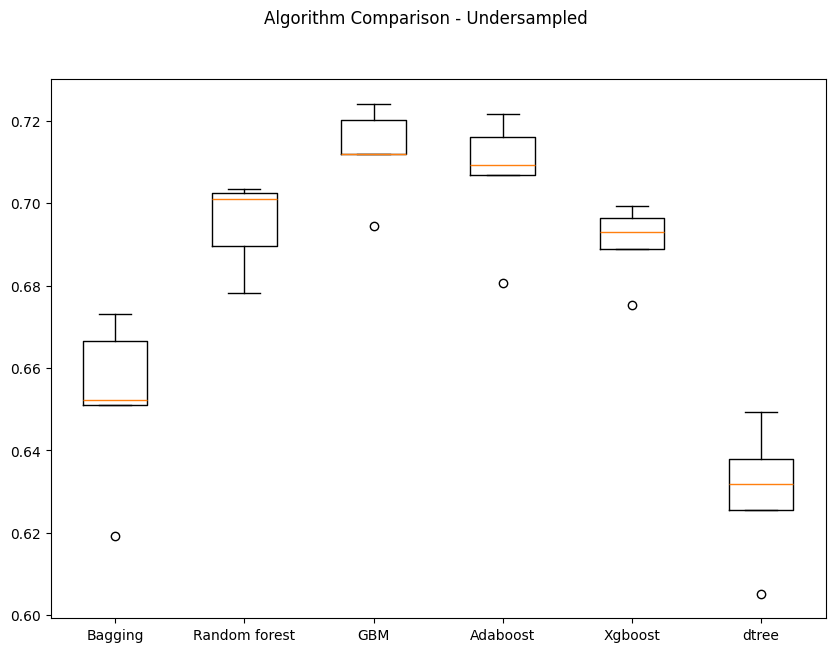

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison - Undersampled")
ax = fig.add_subplot(111)
plt.boxplot(results_un)
ax.set_xticklabels(names)

plt.show()

**Observations from initial model creation on Original, Oversampled and Undersampled Data**


*   Models created on undersampled data is noting considered for hyperparameter tuning as the F1 score is better for original and oversampled data. This is possibly due to the impact of loss of half of the majority class data through undersampling on the data model
*   F1 score is chosen metric as we need to give equal signficant to both the classes in the target variable
*   GBM has the best performance across all 3 variations followed by AdBoost and XgBoost as per the validation performance
*   After creating 16 models, it was obserrved that GBM and AdaBoost have strong performance on the original data. RandomForest and DecisionTree have significant overfitting across all 3 and have perform optimally on (100%) on training data.
*   Hyperparameter tuning will be carried out original data for GBM and AdaBoost and on oversampled data for RandomForest.


## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

### Hyperparameter tuning for GBM on Original Data

In [ ]:
#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'n_estimators': np.int64(100), 'max_features': 0.7, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8281776777004589:


In [ ]:
tuned_gbm = GradientBoostingClassifier(
    random_state=1,
    subsample=1,
    n_estimators=100,
    max_features=0.7,
    learning_rate=0.05,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7, random_state=1,
                           subsample=1)

In [ ]:
# Checking model's performance on training set
gbm_train = model_performance_classification_sklearn(tuned_gbm, X_train, y_train)
gbm_train

,Accuracy,Recall,Precision,F1
0,0.751805,0.841227,0.798082,0.819087


In [ ]:
# Checking model's performance on validation set
gbm_val = model_performance_classification_sklearn(tuned_gbm, X_val, y_val)
gbm_val

,Accuracy,Recall,Precision,F1
0,0.736578,0.832393,0.785841,0.808447


### Hyperparameter tuning for AdaBoost on Original Data

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(20), 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8259918634677593:


In [ ]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.2,
    estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)
tuned_adb.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.2, n_estimators=20, random_state=1)

In [ ]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train)
adb_train

,Accuracy,Recall,Precision,F1
0,0.749608,0.904454,0.764023,0.828328


In [ ]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.735165,0.896333,0.753706,0.818855


### Hyperparameter tuning for RandomForest on Oversampled Data

In [ ]:
# defining model
model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 125, 25],
    "min_samples_leaf": [1, 2, 4, 5, 10],
    "max_features": [0.5, 0.7, 1],
    "max_samples": [0.5, 0.7, 1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, n_jobs=-2, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over) ## Complete the code to fit the model on undersampled data


print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_,randomized_cv.best_score_))


Best parameters are {'n_estimators': 50, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': 1} with CV score=0.8099688971340584:


In [ ]:
tuned_rf = randomized_cv.best_estimator_
tuned_rf.fit(X_train_over, y_train_over)

RandomForestClassifier(max_features=1, max_samples=0.7, min_samples_leaf=2,
                       n_estimators=50, random_state=1)

In [ ]:
# Checking model's performance on training set
rf_train = model_performance_classification_sklearn(tuned_rf, X_train_over, y_train_over)
rf_train

,Accuracy,Recall,Precision,F1
0,0.883124,0.913856,0.860939,0.886609


In [ ]:
# Checking model's performance on validation set
rf_val = model_performance_classification_sklearn(tuned_rf, X_val, y_val)
rf_val

,Accuracy,Recall,Precision,F1
0,0.731554,0.830512,0.781291,0.80515


## Model Performance Summary and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_train.T,
        adb_train.T,
        rf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Original data",
    "Random Forest trained with Oversampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Original data,AdaBoost trained with Original data,Random Forest trained with Oversampled data
Accuracy,0.751805,0.749608,0.883124
Recall,0.841227,0.904454,0.913856
Precision,0.798082,0.764023,0.860939
F1,0.819087,0.828328,0.886609


In [ ]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [ gbm_val.T, adb_val.T, rf_val.T], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Original data",
    "Random Forest trained with Oversampled data",
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Gradient boosting trained with Original data,AdaBoost trained with Original data,Random Forest trained with Oversampled data
Accuracy,0.736578,0.735165,0.731554
Recall,0.832393,0.896333,0.830512
Precision,0.785841,0.753706,0.781291
F1,0.808447,0.818855,0.805150


Observations


*   AdaBoost on Original data has given the best F1 score so we will recommend this.


In [ ]:
# Let's check the performance on test set
ada_test = model_performance_classification_sklearn(tuned_adb, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.727786,0.895182,0.747302,0.814585


- The Adaboost model trained on undersampled data has given ~80% recall on the test set
- This performance is in line with what we achieved with this model on the train and validation sets
- So, this is a generalized model

### Feature Importance

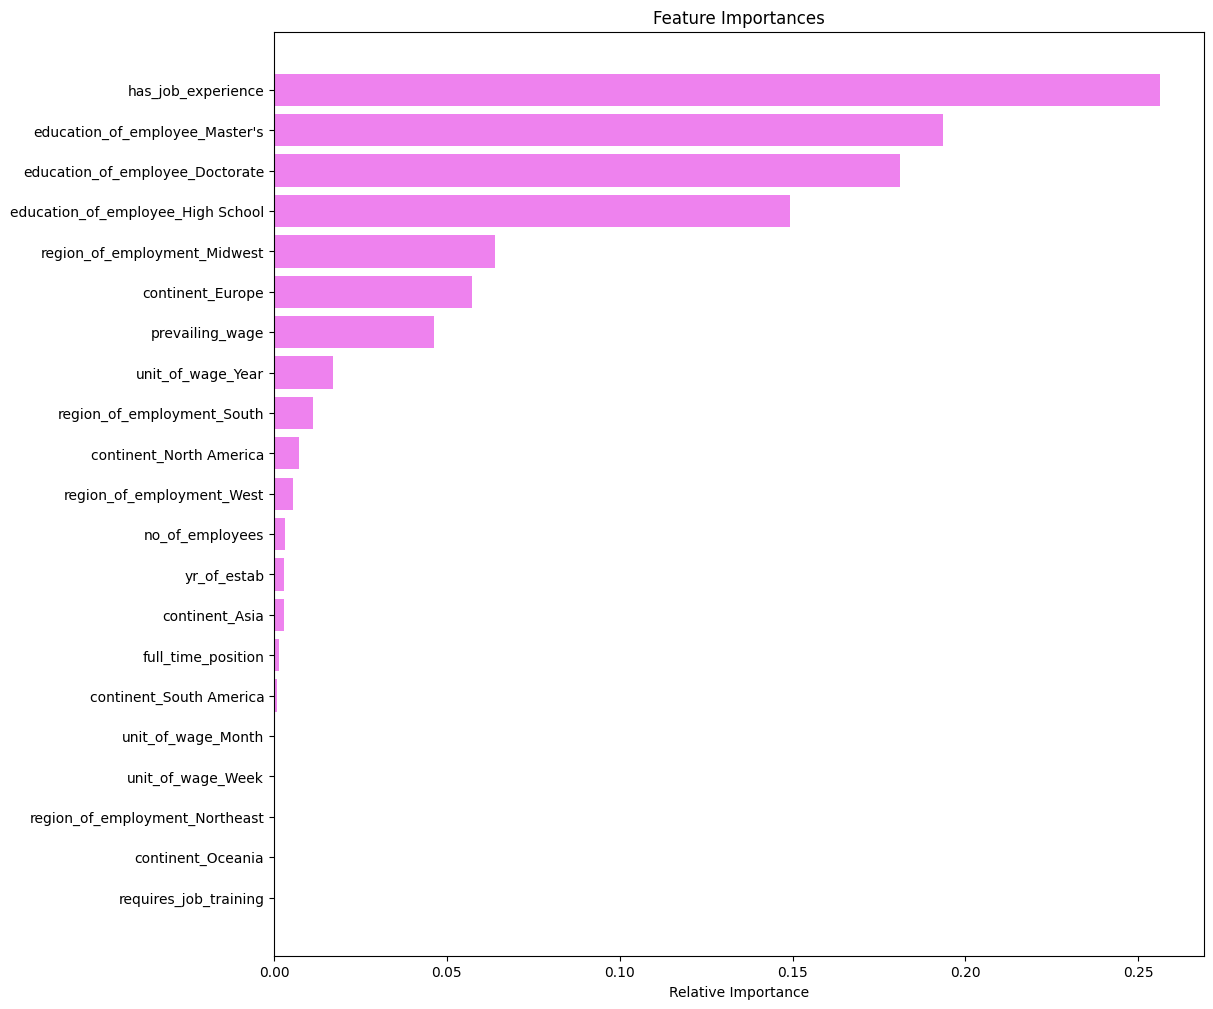

In [ ]:
feature_names = X_train.columns
importances = tuned_adb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()



*   Prior Job Experience and Education Level of the applicant has the most importance




## Actionable Insights and Recommendations



*   The AdaBoost model provides the best balance between Precision and Recall. Given that we need to give equal importance to both the classes we recommend using this as the final data model for classification.
*   Give preference to applicants with prior job experience.
*   Target applicants having higher education such as a Masters or Doctorate.




<font size=6 color='blue'>Power Ahead</font>
___

## Convert to HTML

In [ ]:
!jupyter nbconvert "/content/drive/MyDrive/Learning/UT Austin/03 - Advanced Machine Learning/Project/Thomas_Joseph_EasyVisa_Full_Code_Notebook.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Learning/UT Austin/03 - Advanced Machine Learning/Project/Thomas_Joseph_EasyVisa_Full_Code_Notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 17 image(s).
[NbConvertApp] Writing 1295952 bytes to /content/drive/MyDrive/Learning/UT Austin/03 - Advanced Machine Learning/Project/Thomas_Joseph_EasyVisa_Full_Code_Notebook.html
